In [22]:
# ==========================================
# CELL 1 — WHY THIS TIMING WORKS (READ BEFORE RUNNING)
# ==========================================
# NIFTY trades roughly 9:15am-3:30pm IST. The S&P 500 trades roughly
# 9:30am-4:00pm ET, which is about 7:00pm-1:30am IST (or 8:00pm-2:30am IST
# during US daylight saving). That means the PREVIOUS US session's full
# close is always known before NIFTY opens the next morning.
#
# So "predict today's NIFTY IV using YESTERDAY's US close" is a genuinely
# legitimate, lookahead-free feature - it reflects real, available
# information, not a coincidence of alignment. This is a well-known real
# effect: overnight moves in US markets often show up in the next Asian /
# Indian session because global risk sentiment doesn't reset at midnight.

import os
import numpy as np
import pandas as pd

folder = r"C:\Users\ASUS\Desktop\volPredict"

print("=== LOADING US MARKET DATA (S&P 500 + US VIX) ===")

# S&P 500 - proxy total-return index (source: SteelCerberus/us-market-data
# on GitHub). Covers our full window with real daily granularity.
sp500 = pd.read_csv(os.path.join(folder, "sp500_daily.csv"), parse_dates=["Date"])
sp500 = sp500[["Date", "Close"]].rename(columns={"Close": "SP500_Close"})
sp500 = sp500.dropna().sort_values("Date").reset_index(drop=True)
print(f"✓ S&P 500: {len(sp500):,} days, {sp500['Date'].min().date()} to {sp500['Date'].max().date()}")

# US VIX (CBOE Volatility Index) - source: datasets/finance-vix on GitHub
us_vix = pd.read_csv(os.path.join(folder, "vix_us_daily.csv"))
us_vix["Date"] = pd.to_datetime(us_vix["DATE"])
us_vix = us_vix[["Date", "CLOSE"]].rename(columns={"CLOSE": "US_VIX_Close"})
us_vix = us_vix.dropna().sort_values("Date").reset_index(drop=True)
print(f"✓ US VIX: {len(us_vix):,} days, {us_vix['Date'].min().date()} to {us_vix['Date'].max().date()}")

=== LOADING US MARKET DATA (S&P 500 + US VIX) ===
✓ S&P 500: 35,254 days, 1885-03-20 to 2025-12-19
✓ US VIX: 9,251 days, 1990-01-02 to 2026-08-14


In [23]:
# ==========================================
# CELL 2 — BUILD YESTERDAY'S US SESSION AS A FEATURE FOR TODAY'S NIFTY DATE
# ==========================================
# Both markets have their own holiday calendars, so US and Indian trading
# dates don't line up 1-to-1. The correct approach is NOT to merge on
# matching calendar dates - it's to attach, for each NIFTY trading day, the
# MOST RECENT US trading day that closed strictly BEFORE that NIFTY date.
# pandas merge_asof does exactly this safely (direction='backward' means
# "look at the most recent US row at or before this date" - we then shift
# by one day of buffer implicitly since NIFTY's date itself has no US data).

us_market = pd.merge(sp500, us_vix, on="Date", how="outer").sort_values("Date").reset_index(drop=True)
us_market["SP500_LogReturn"] = np.log(us_market["SP500_Close"] / us_market["SP500_Close"].shift(1))
us_market["US_VIX_chg1d"] = us_market["US_VIX_Close"].diff(1)

print("=== ATTACHING PREVIOUS US SESSION TO EACH NIFTY DATE ===")

iv_feat = pd.read_csv(os.path.join(folder, "daily_volatility_features.csv"), parse_dates=["Date"])
iv_feat = iv_feat.sort_values("Date").reset_index(drop=True)

df = pd.merge_asof(
    iv_feat, us_market,
    on="Date",
    direction="backward",
    allow_exact_matches=False,   # never use a US row dated the SAME calendar day as NIFTY
)

n_matched = df["SP500_Close"].notna().sum()
print(f"✓ Matched previous US session for {n_matched:,} / {len(df):,} NIFTY trading days")

df = df.rename(columns={
    "SP500_Close": "US_SP500_prev_close",
    "SP500_LogReturn": "US_SP500_prev_return",
    "US_VIX_Close": "US_VIX_prev_close",
    "US_VIX_chg1d": "US_VIX_prev_chg1d",
})

print(df[["Date", "US_SP500_prev_return", "US_VIX_prev_close", "ATM_IV_30D"]].tail(10))

=== ATTACHING PREVIOUS US SESSION TO EACH NIFTY DATE ===
✓ Matched previous US session for 637 / 656 NIFTY trading days
          Date  US_SP500_prev_return  US_VIX_prev_close  ATM_IV_30D
646 2025-06-17              0.009469              19.11    0.138861
647 2025-06-18             -0.008582              21.60    0.140620
648 2025-06-19             -0.000151              20.14    0.137364
649 2025-06-20                   NaN              22.17    0.131182
650 2025-06-23                   NaN              20.62    0.138533
651 2025-06-24              0.009829              19.83    0.132375
652 2025-06-25              0.010987              17.48    0.125095
653 2025-06-26              0.000560              16.76    0.119896
654 2025-06-27              0.007793              16.59    0.117079
655 2025-06-30              0.004956              16.32    0.121933


In [24]:
# ==========================================
# CELL 3 — SANITY CHECK: DOES US OVERNIGHT MOVE ACTUALLY CORRELATE?
# ==========================================
# Before building a model, check the raw relationship. If there's no
# correlation at all, a model won't find one either - better to know now.

check_df = df[["Date", "US_SP500_prev_return", "US_VIX_prev_chg1d", "ATM_IV_30D"]].dropna().copy()
check_df["NIFTY_IV_chg1d"] = check_df["ATM_IV_30D"].diff(1)
check_df = check_df.dropna()

print("=== CORRELATION CHECK: US OVERNIGHT MOVE vs NEXT-DAY NIFTY IV CHANGE ===")
corr = check_df[["US_SP500_prev_return", "US_VIX_prev_chg1d", "NIFTY_IV_chg1d"]].corr()
print(corr)
print()
print("Interpretation: a negative correlation between US_SP500_prev_return and")
print("NIFTY_IV_chg1d would match the classic pattern - US market falls ->")
print("NIFTY IV rises the next day (fear spreads across markets overnight).")
print("A positive correlation between US_VIX_prev_chg1d and NIFTY_IV_chg1d")
print("would mean US fear directly co-moves with Indian fear.")

=== CORRELATION CHECK: US OVERNIGHT MOVE vs NEXT-DAY NIFTY IV CHANGE ===
                      US_SP500_prev_return  US_VIX_prev_chg1d  NIFTY_IV_chg1d
US_SP500_prev_return              1.000000          -0.713614       -0.149927
US_VIX_prev_chg1d                -0.713614           1.000000        0.192816
NIFTY_IV_chg1d                   -0.149927           0.192816        1.000000

Interpretation: a negative correlation between US_SP500_prev_return and
NIFTY_IV_chg1d would match the classic pattern - US market falls ->
NIFTY IV rises the next day (fear spreads across markets overnight).
A positive correlation between US_VIX_prev_chg1d and NIFTY_IV_chg1d
would mean US fear directly co-moves with Indian fear.


In [25]:
# ==========================================
# CELL 4 — BUILD PREDICTION TARGET AND FEATURE SET
# ==========================================
# Target: today's ATM_IV_30D level, and its 1-day change - both are
# genuinely UNKNOWN at the time yesterday's US session closed, so predicting
# them from that prior information is a fair test.

print("=== BUILDING FEATURE SET ===")

df["ATM_IV_30D_prev"] = df["ATM_IV_30D"].shift(1)   # yesterday's NIFTY IV - a natural baseline feature
df["ATM_IV_30D_chg1d"] = df["ATM_IV_30D"] - df["ATM_IV_30D_prev"]

# Skew was previously MISSING from this notebook's features entirely, even
# though daily_volatility_features.csv already provides SKEW_14D/SKEW_30D.
# We lag them by one day (yesterday's skew, known before today's open) since
# using today's own skew as a feature would leak same-day information.
df["SKEW_30D_prev"] = df["SKEW_30D"].shift(1)
df["SKEW_14D_prev"] = df["SKEW_14D"].shift(1)
df["SKEW_30D_chg1d"] = df["SKEW_30D_prev"] - df["SKEW_30D"].shift(2)

# If notebook 4's fitted smile_features.csv is available, bring in its
# 7D/14D/30D skew and curvature too - genuinely richer than the raw
# daily_volatility_features.csv skew, since it's fit across all strikes
# rather than a single put/call pair difference.
smile_feat_path = os.path.join(folder, "smile_features.csv")
if os.path.exists(smile_feat_path):
    smile_feat = pd.read_csv(smile_feat_path, parse_dates=["Date"])
    smile_cols = [c for c in ["Date", "Smile_Skew_7D", "Smile_Skew_14D", "Smile_Skew_30D",
                               "Smile_Curv_7D", "Smile_Curv_14D", "Smile_Curv_30D"] if c in smile_feat.columns]
    df = pd.merge(df, smile_feat[smile_cols], on="Date", how="left")
    for c in smile_cols:
        if c != "Date":
            df[f"{c}_prev"] = df[c].shift(1)
    HAVE_FITTED_SMILE = True
    print(f"✓ Merged fitted smile skew/curvature from notebook 4 ({[c for c in smile_cols if c!='Date']})")
else:
    HAVE_FITTED_SMILE = False
    print("⚠️ smile_features.csv not found - using only raw SKEW_14D/30D from daily_volatility_features.csv")

FEATURE_COLS = [
    "ATM_IV_30D_prev",       # yesterday's NIFTY IV level (strong baseline predictor on its own)
    "SKEW_30D_prev",         # yesterday's put/call IV skew (30D)
    "SKEW_14D_prev",         # yesterday's put/call IV skew (14D)
    "US_SP500_prev_return",  # the actual new information from this notebook's idea
    "US_VIX_prev_close",
    "US_VIX_prev_chg1d",
]
if HAVE_FITTED_SMILE:
    FEATURE_COLS += [f"{c}_prev" for c in smile_cols if c != "Date"]

TARGET_COL = "ATM_IV_30D"   # predict TODAY's level using only info known before today's NIFTY open

model_df = df[["Date"] + FEATURE_COLS + [TARGET_COL]].dropna().reset_index(drop=True)
print(f"✓ Final modeling table: {len(model_df):,} rows, {len(FEATURE_COLS)} features")
print(f"  Features: {FEATURE_COLS}")
print(f"  Date range: {model_df['Date'].min().date()} to {model_df['Date'].max().date()}")

=== BUILDING FEATURE SET ===
✓ Merged fitted smile skew/curvature from notebook 4 (['Smile_Skew_7D', 'Smile_Skew_14D', 'Smile_Skew_30D', 'Smile_Curv_7D', 'Smile_Curv_14D', 'Smile_Curv_30D'])
✓ Final modeling table: 615 rows, 12 features
  Features: ['ATM_IV_30D_prev', 'SKEW_30D_prev', 'SKEW_14D_prev', 'US_SP500_prev_return', 'US_VIX_prev_close', 'US_VIX_prev_chg1d', 'Smile_Skew_7D_prev', 'Smile_Skew_14D_prev', 'Smile_Skew_30D_prev', 'Smile_Curv_7D_prev', 'Smile_Curv_14D_prev', 'Smile_Curv_30D_prev']
  Date range: 2021-01-04 to 2025-06-30


In [26]:
# ==========================================
# CELL 5 — TRAIN / TEST SPLIT (TIME-ORDERED)
# ==========================================
print("=== SPLITTING TRAIN / TEST BY DATE ===")

split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

print(f"Train: {len(train_df):,} rows, {train_df['Date'].min().date()} to {train_df['Date'].max().date()}")
print(f"Test:  {len(test_df):,} rows, {test_df['Date'].min().date()} to {test_df['Date'].max().date()}")

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]

=== SPLITTING TRAIN / TEST BY DATE ===
Train: 492 rows, 2021-01-04 to 2024-11-08
Test:  123 rows, 2024-11-22 to 2025-06-30


In [27]:
# ==========================================
# CELL 6 — BASELINES + MODEL, WITH AND WITHOUT THE US FEATURES
# ==========================================
# The key comparison this notebook exists to answer: does adding SKEW and/or
# S&P 500 / US VIX information actually improve on just using yesterday's
# NIFTY IV level alone? We isolate each addition step by step.

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

print("=== COMPARISON: NIFTY-ONLY vs NIFTY+SKEW vs NIFTY+SKEW+US ===")

def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:<38} MAE={mae:.5f}   RMSE={rmse:.5f}")
    return mae, rmse

# Baseline 1: naive persistence - "today's IV = yesterday's IV"
naive_pred = test_df["ATM_IV_30D_prev"].values
report("Naive persistence (yesterday's IV)", y_test, naive_pred)

# Baseline 2: linear regression using ONLY yesterday's NIFTY IV (no US data)
nifty_only_cols = ["ATM_IV_30D_prev"]
lin_nifty_only = LinearRegression()
lin_nifty_only.fit(train_df[nifty_only_cols], y_train)
pred_nifty_only = lin_nifty_only.predict(test_df[nifty_only_cols])
report("Linear (NIFTY-only)", y_test, pred_nifty_only)

# Intermediate: NIFTY IV level + SKEW only (no US data) - isolates what skew
# alone contributes, before adding the cross-market signal on top.
skew_cols = [c for c in FEATURE_COLS if "SKEW" in c or "Skew" in c]
nifty_skew_cols = nifty_only_cols + skew_cols
lin_nifty_skew = LinearRegression()
lin_nifty_skew.fit(train_df[nifty_skew_cols], y_train)
pred_nifty_skew = lin_nifty_skew.predict(test_df[nifty_skew_cols])
report("Linear (NIFTY + skew, no US)", y_test, pred_nifty_skew)

# Model: linear regression WITH US S&P500/VIX features added (+ skew, all features)
lin_with_us = LinearRegression()
lin_with_us.fit(X_train, y_train)
pred_with_us = lin_with_us.predict(X_test)
report("Linear (NIFTY + skew + US)", y_test, pred_with_us)

# Gradient boosting, NIFTY-only
gbr_nifty_only = GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42)
gbr_nifty_only.fit(train_df[nifty_only_cols], y_train)
gbr_pred_nifty_only = gbr_nifty_only.predict(test_df[nifty_only_cols])
report("GBM (NIFTY-only)", y_test, gbr_pred_nifty_only)

# Gradient boosting, NIFTY + skew only
gbr_nifty_skew = GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42)
gbr_nifty_skew.fit(train_df[nifty_skew_cols], y_train)
gbr_pred_nifty_skew = gbr_nifty_skew.predict(test_df[nifty_skew_cols])
report("GBM (NIFTY + skew, no US)", y_test, gbr_pred_nifty_skew)

# Gradient boosting WITH US features (+ skew, all features)
gbr_with_us = GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42)
gbr_with_us.fit(X_train, y_train)
gbr_pred_with_us = gbr_with_us.predict(X_test)
report("GBM (NIFTY + skew + US)", y_test, gbr_pred_with_us)

print()
print("--- Feature importance (GBM with US features) ---")
importance = pd.Series(gbr_with_us.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(importance)

=== COMPARISON: NIFTY-ONLY vs NIFTY+SKEW vs NIFTY+SKEW+US ===
Naive persistence (yesterday's IV)     MAE=0.00676   RMSE=0.01175
Linear (NIFTY-only)                    MAE=0.00668   RMSE=0.01149
Linear (NIFTY + skew, no US)           MAE=0.00718   RMSE=0.01188
Linear (NIFTY + skew + US)             MAE=0.00735   RMSE=0.01153
GBM (NIFTY-only)                       MAE=0.00701   RMSE=0.01174
GBM (NIFTY + skew, no US)              MAE=0.00742   RMSE=0.01300
GBM (NIFTY + skew + US)                MAE=0.00772   RMSE=0.01196

--- Feature importance (GBM with US features) ---
ATM_IV_30D_prev         0.946679
US_VIX_prev_close       0.022990
Smile_Skew_14D_prev     0.017331
US_VIX_prev_chg1d       0.004855
US_SP500_prev_return    0.002212
Smile_Curv_30D_prev     0.001887
SKEW_30D_prev           0.001193
Smile_Curv_14D_prev     0.001065
Smile_Curv_7D_prev      0.001014
Smile_Skew_7D_prev      0.000465
SKEW_14D_prev           0.000288
Smile_Skew_30D_prev     0.000022
dtype: float64


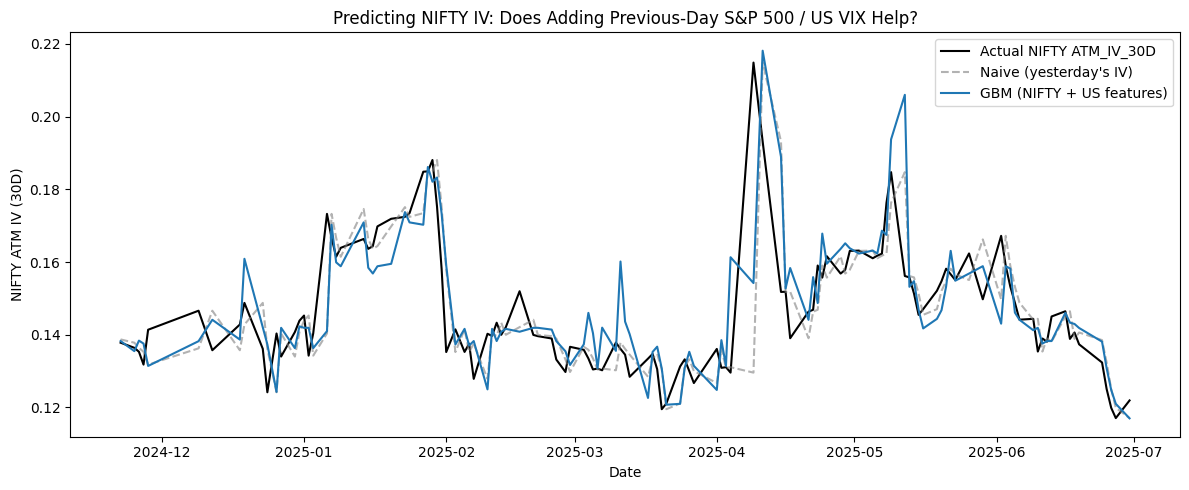

✓ Since NIFTY IV is highly persistent day-to-day, naive persistence is
  already a strong baseline. The real test is whether adding US features
  meaningfully beats the NIFTY-only model above, not just the naive one.


In [28]:
# ==========================================
# CELL 7 — VISUALIZE: DID ADDING US DATA HELP?
# ==========================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_df["Date"], y_test, label="Actual NIFTY ATM_IV_30D", color="black", linewidth=1.5)
ax.plot(test_df["Date"], naive_pred, label="Naive (yesterday's IV)", color="gray", linestyle="--", alpha=0.6)
ax.plot(test_df["Date"], gbr_pred_with_us, label="GBM (NIFTY + US features)", color="tab:blue")
ax.set_xlabel("Date")
ax.set_ylabel("NIFTY ATM IV (30D)")
ax.set_title("Predicting NIFTY IV: Does Adding Previous-Day S&P 500 / US VIX Help?")
ax.legend()
plt.tight_layout()
plt.savefig("nifty_iv_us_spillover_test.png", dpi=100)
plt.show()

print("✓ Since NIFTY IV is highly persistent day-to-day, naive persistence is")
print("  already a strong baseline. The real test is whether adding US features")
print("  meaningfully beats the NIFTY-only model above, not just the naive one.")